In [1]:
import os
import numpy as np
import pandas as pd

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# DATA COLLECTION

In [2]:
import requests
import pandas as pd

def generate_global_wordlist():
    urls = {
        "SOWPODS":        "https://raw.githubusercontent.com/powerlanguage/guess-my-word/master/wordlist/sowpods.txt",
        "Wordle_Allowed": "https://raw.githubusercontent.com/tabatkins/wordle-list/main/words",
        "Big_Kahuna":     "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt",
    }
    master_set = set()
    for name, url in urls.items():
        print(f"Syncing {name}...")
        try:
            resp = requests.get(url, timeout=30)
            if resp.status_code == 200:
                before = len(master_set)
                for line in resp.text.splitlines():
                    w = line.strip().lower()
                    if len(w) == 5 and w.isalpha():
                        master_set.add(w)
                print(f"  -> Added {len(master_set) - before} unique words.")
            else:
                print(f"  -> Error: status {resp.status_code}")
        except Exception as e:
            print(f"  -> Connection error: {e}")

    final_list = sorted(master_set)
    df = pd.DataFrame(final_list, columns=['word'])
    df.to_csv('combined_5_letter_words.csv', index=False)
    print("-" * 40)
    print(f"COMPLETE: {len(final_list)} unique words saved.")
    return df

word_df = generate_global_wordlist()
print(word_df.head(10))

Syncing SOWPODS...
  -> Added 12478 unique words.
Syncing Wordle_Allowed...
  -> Added 2389 unique words.
Syncing Big_Kahuna...
  -> Added 5292 unique words.
----------------------------------------
COMPLETE: 20159 unique words saved.
    word
0  aahed
1  aalii
2  aapas
3  aargh
4  aaron
5  aarti
6  abaca
7  abaci
8  aback
9  abacs


# EXPLORATORY DATA ANALYSIS

Dataset size: 20159 words



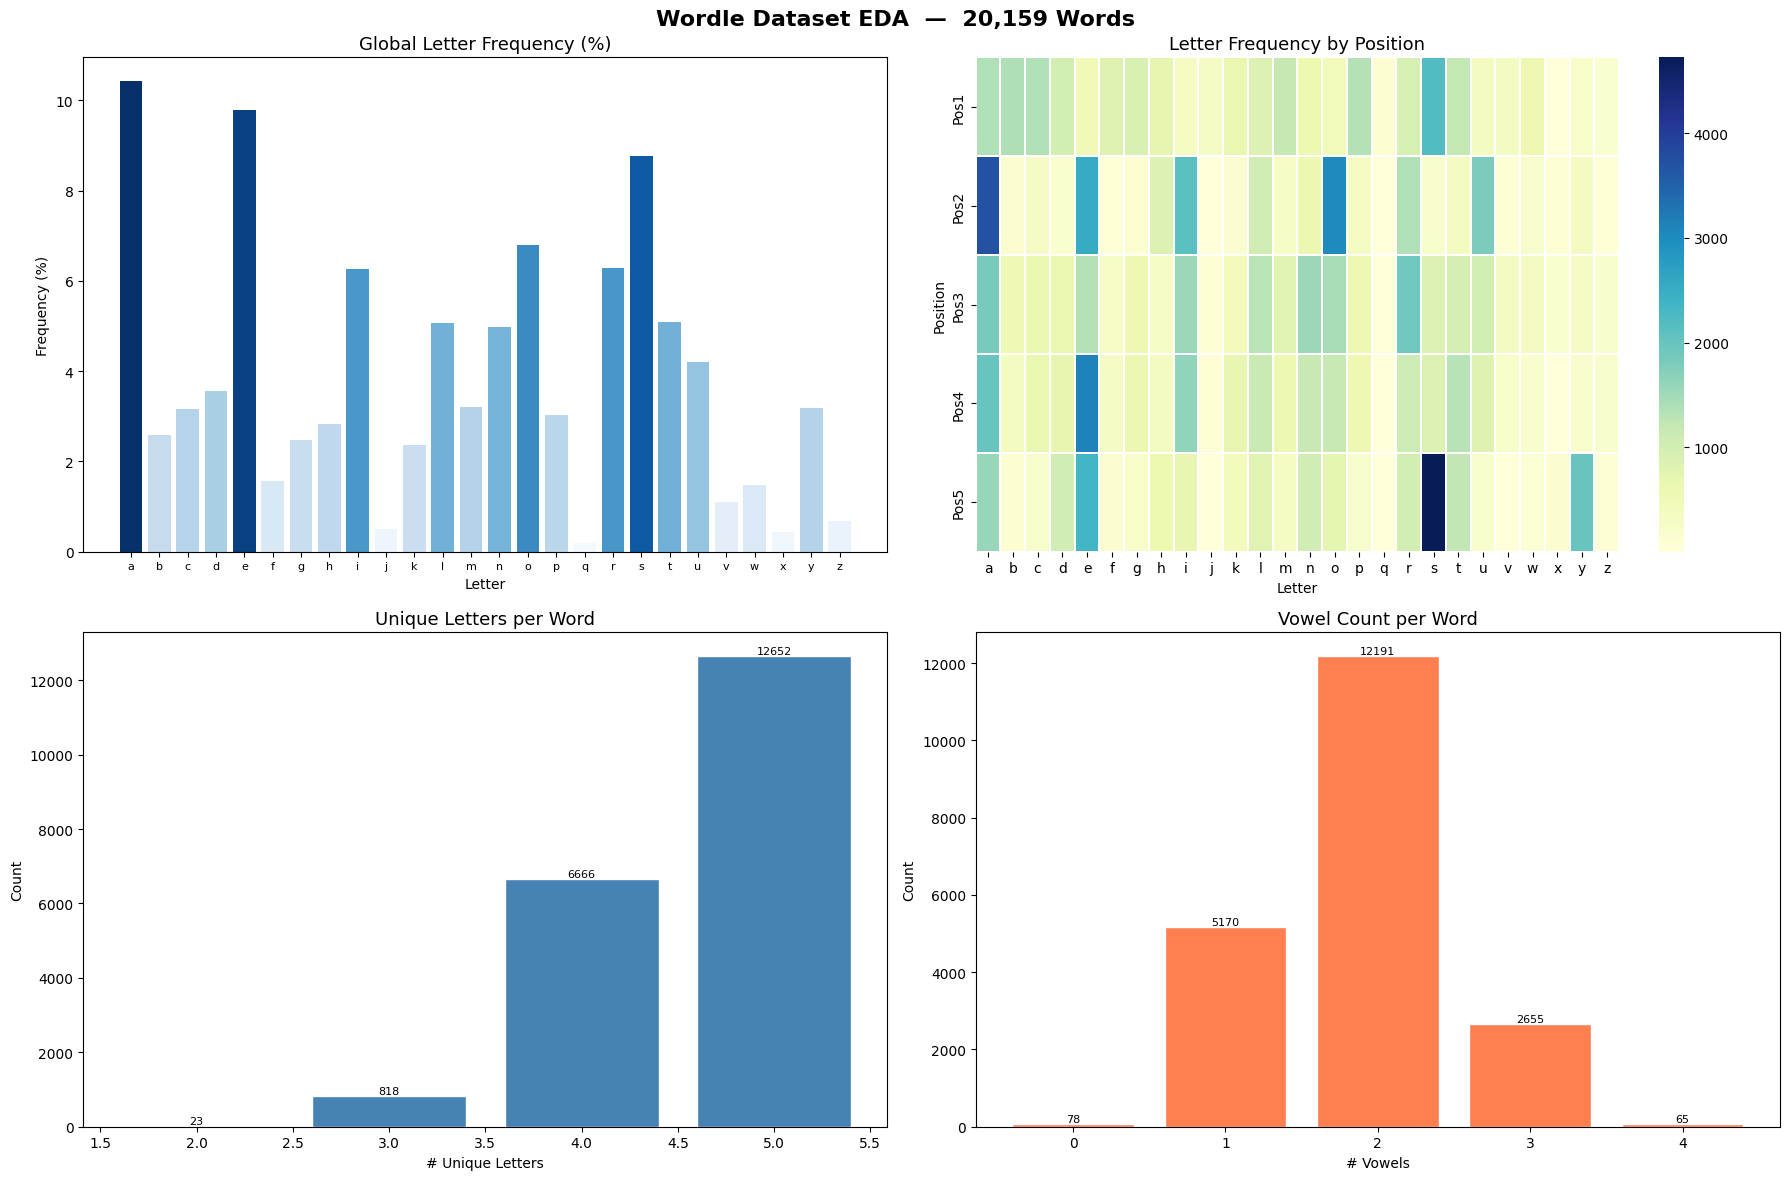

--- Top 10 Most Common Letters ---
Letter  Count       Pct
     a  10516 10.433057
     e   9865  9.787192
     s   8843  8.773253
     o   6852  6.797956
     r   6344  6.293963
     i   6315  6.265192
     t   5122  5.081601
     l   5114  5.073664
     n   5008  4.968500
     u   4229  4.195645

--- Unique-letter distribution ---
  2 unique letters: 23 words
  3 unique letters: 818 words
  4 unique letters: 6,666 words
  5 unique letters: 12,652 words

--- Vowel distribution ---
  0 vowels: 78 words
  1 vowels: 5,170 words
  2 vowels: 12,191 words
  3 vowels: 2,655 words
  4 vowels: 65 words


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df   = pd.read_csv('combined_5_letter_words.csv')
WORDS = df['word'].astype(str).tolist()
N_WORDS = len(WORDS)
print(f"Dataset size: {N_WORDS} words\n")

# -- 1. Global Letter Frequency --
all_text     = "".join(WORDS)
global_cnt   = Counter(all_text)
global_freq  = pd.DataFrame(global_cnt.most_common(), columns=['Letter', 'Count'])
global_freq['Pct'] = global_freq['Count'] / len(all_text) * 100

# -- 2. Positional Frequency Matrix --
alphabet  = [chr(i + ord('a')) for i in range(26)]
pos_matrix = np.zeros((5, 26))
for w in WORDS:
    for i, c in enumerate(w):
        if 'a' <= c <= 'z':
            pos_matrix[i, ord(c) - ord('a')] += 1
pos_df = pd.DataFrame(pos_matrix, columns=alphabet, index=['Pos1','Pos2','Pos3','Pos4','Pos5'])

# -- 3. Unique-letters per word --
unique_counts = [len(set(w)) for w in WORDS]
uc_dist       = Counter(unique_counts)

# -- 4. Vowel count distribution --
VOWELS = set('aeiou')
vowel_counts = [sum(c in VOWELS for c in w) for w in WORDS]
vc_dist      = Counter(vowel_counts)

# ----- PLOTS -----
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Wordle Dataset EDA  —  {N_WORDS:,} Words', fontsize=16, fontweight='bold')

# Plot 1: Top 26 global letter frequencies
ax = axes[0, 0]
top = global_freq.sort_values('Letter').reset_index(drop=True)
bars = ax.bar(top['Letter'], top['Pct'], color=plt.cm.Blues(top['Pct'] / top['Pct'].max()))
ax.set_title('Global Letter Frequency (%)', fontsize=13)
ax.set_xlabel('Letter'); ax.set_ylabel('Frequency (%)')
ax.tick_params(axis='x', labelsize=8)

# Plot 2: Positional Frequency Heatmap
ax = axes[0, 1]
sns.heatmap(pos_df, annot=False, cmap='YlGnBu', ax=ax, linewidths=0.3)
ax.set_title('Letter Frequency by Position', fontsize=13)
ax.set_xlabel('Letter'); ax.set_ylabel('Position')

# Plot 3: Unique letters per word
ax = axes[1, 0]
x_uc = sorted(uc_dist.keys())
y_uc = [uc_dist[k] for k in x_uc]
ax.bar(x_uc, y_uc, color='steelblue', edgecolor='white')
ax.set_title('Unique Letters per Word', fontsize=13)
ax.set_xlabel('# Unique Letters'); ax.set_ylabel('Count')
for xi, yi in zip(x_uc, y_uc):
    ax.text(xi, yi + 50, str(yi), ha='center', fontsize=8)

# Plot 4: Vowel count per word
ax = axes[1, 1]
x_vc = sorted(vc_dist.keys())
y_vc = [vc_dist[k] for k in x_vc]
ax.bar(x_vc, y_vc, color='coral', edgecolor='white')
ax.set_title('Vowel Count per Word', fontsize=13)
ax.set_xlabel('# Vowels'); ax.set_ylabel('Count')
for xi, yi in zip(x_vc, y_vc):
    ax.text(xi, yi + 50, str(yi), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_wordle.png', dpi=120, bbox_inches='tight')
plt.show()

print("--- Top 10 Most Common Letters ---")
print(global_freq.head(10).to_string(index=False))
print(f"\n--- Unique-letter distribution ---")
for k in sorted(uc_dist): print(f"  {k} unique letters: {uc_dist[k]:,} words")
print(f"\n--- Vowel distribution ---")
for k in sorted(vc_dist): print(f"  {k} vowels: {vc_dist[k]:,} words")

# SHARED GPU INFRASTRUCTURE

In [4]:
import torch
import numpy as np
import pandas as pd
import time
from collections import Counter

# ---- Dataset ----
word_df = pd.read_csv('combined_5_letter_words.csv')
words   = word_df['word'].astype(str).values
n       = len(words)
DEVICE  = 'cuda'
ALL_GREEN = 242   # base-3 encoding of [2,2,2,2,2]

word_ints = torch.tensor(
    [[ord(c) - ord('a') for c in w] for w in words],
    device=DEVICE, dtype=torch.int8
)
PWR = torch.tensor([1, 3, 9, 27, 81], device=DEVICE, dtype=torch.int32)

print(f"Dataset : {n} words | Device : {DEVICE}")

# ---- Correct feedback matrix builder ----
# Handles duplicate letters properly (official Wordle rules).
# FM[guess_idx, target_idx]  →  uint8 pattern (0–242)
def _build_feedback_matrix():
    fb = np.zeros((n, n), dtype=np.uint8)
    t0 = time.time()
    for gi in range(n):
        g   = word_ints[gi]           # (5,)
        tgt = word_ints               # (n, 5)
        pat = torch.zeros(n, 5, dtype=torch.int8, device=DEVICE)

        # GREEN pass: exact position match
        grn = (tgt == g.unsqueeze(0))  # (n, 5) bool
        pat[grn] = 2

        # YELLOW pass: correct letter, wrong position — duplicate-safe
        # For each letter value v:
        #   available[v] = # non-green positions in target that hold v
        #   walk guess positions with v left→right; mark yellow until quota used
        for v in range(26):
            avail = ((~grn) & (tgt == v)).sum(1).to(torch.int32)   # (n,)
            gpos  = (g == v).nonzero(as_tuple=True)[0]
            if gpos.numel() == 0:
                continue
            used = torch.zeros(n, dtype=torch.int32, device=DEVICE)
            for p in gpos:
                p = p.item()
                can = (~grn[:, p]) & (used < avail)
                pat[can, p] = 1
                used += can.to(torch.int32)

        # Encode pattern as base-3 integer (0–242)
        fb[gi] = (pat.to(torch.int32) * PWR.unsqueeze(0)).sum(1).cpu().numpy()

        if gi % 2000 == 0 and gi > 0:
            elapsed = time.time() - t0
            eta     = elapsed / gi * (n - gi)
            print(f"  Building FM: {gi}/{n} | {elapsed:.0f}s elapsed | ETA {eta:.0f}s")

    print(f"  FM complete: {n}×{n} in {time.time()-t0:.1f}s | {fb.nbytes/1e6:.0f} MB")
    return fb

if 'FM' not in dir():
    print("Building correct feedback matrix (shared by Models 2–8)...")
    FM = _build_feedback_matrix()
else:
    print("FM already in memory — skipping rebuild.")

# ---- Diagnostic: verify feedback correctness ----
def _verify():
    cases = [
        ('crane','trace', [1,2,2,0,2]),
        ('speed','spell', [2,2,2,0,0]),
        ('hello','hello', [2,2,2,2,2]),
        ('aaaaa','bbbbb', [0,0,0,0,0]),
    ]
    print("\nFeedback matrix verification:")
    for guess, tgt, exp in cases:
        if guess not in words or tgt not in words:
            print(f"  SKIP (not in vocab): {guess} vs {tgt}"); continue
        gi = int(np.where(words == guess)[0][0])
        ti = int(np.where(words == tgt)[0][0])
        enc = int(FM[gi][ti])
        dec = [(enc // (3**p)) % 3 for p in range(5)]
        exp_enc = sum(e*(3**i) for i,e in enumerate(exp))
        status  = "PASS" if dec == exp else "FAIL"
        print(f"  {status} | {guess} vs {tgt} | got {dec} | expected {exp}")

_verify()

# ---- Vectorized entropy scorer (GPU scatter_add) ----
def entropy_all(cand_idx, chunk=512):
    """
    Returns shape-(n,) float32 array.
    scores[w] = Shannon entropy of FM[w, cand_idx] distribution.
    Higher = word w gives more information when guessing against cand_idx.
    """
    M   = len(cand_idx)
    out = np.zeros(n, dtype=np.float32)
    for s in range(0, n, chunk):
        e   = min(s + chunk, n)
        sub = torch.from_numpy(FM[s:e][:, cand_idx].astype(np.int64)).to(DEVICE)
        cnt = torch.zeros(e - s, 243, dtype=torch.float32, device=DEVICE)
        cnt.scatter_add_(1, sub, torch.ones_like(sub, dtype=torch.float32))
        p   = cnt / M
        msk = p > 0
        lp  = torch.zeros_like(p)
        lp[msk] = torch.log2(p[msk])
        out[s:e] = (-(p * lp).sum(1)).cpu().numpy()
    return out

# ---- Vectorized minimax scorer (GPU scatter_add) ----
def minimax_all(cand_idx, chunk=512):
    """
    Returns shape-(n,) int32 array.
    scores[w] = worst-case bucket size when word w is guessed against cand_idx.
    Lower = better (argmin = best minimax guess).
    """
    M   = len(cand_idx)
    out = np.zeros(n, dtype=np.int32)
    for s in range(0, n, chunk):
        e   = min(s + chunk, n)
        sub = torch.from_numpy(FM[s:e][:, cand_idx].astype(np.int64)).to(DEVICE)
        cnt = torch.zeros(e - s, 243, dtype=torch.int32, device=DEVICE)
        cnt.scatter_add_(1, sub, torch.ones_like(sub, dtype=torch.int32))
        out[s:e] = cnt.max(1).values.cpu().numpy()
    return out

# ---- Expected-steps scorer (for Model 4 DP) ----
def dp_score_all(cand_idx, chunk=512):
    """
    Returns shape-(n,) float32.
    score[w] = sum_p( (cnt_p/M) * (log2(cnt_p)+1) )
    Approximates expected total future steps for guess w.
    Lower = better (argmin = best DP guess).
    """
    M   = len(cand_idx)
    out = np.full(n, np.inf, dtype=np.float32)
    for s in range(0, n, chunk):
        e   = min(s + chunk, n)
        sub = torch.from_numpy(FM[s:e][:, cand_idx].astype(np.int64)).to(DEVICE)
        cnt = torch.zeros(e - s, 243, dtype=torch.float32, device=DEVICE)
        cnt.scatter_add_(1, sub, torch.ones_like(sub, dtype=torch.float32))
        # Expected depth: sum_p (cnt_p/M) * (log2(cnt_p)+1)  for cnt_p > 0
        msk   = cnt > 0
        score = torch.zeros(e - s, 243, dtype=torch.float32, device=DEVICE)
        score[msk] = (cnt[msk] / M) * (torch.log2(cnt[msk]) + 1)
        out[s:e] = score.sum(1).cpu().numpy()
    return out

# ---- Uniform progress logger ----
def progress_log(i, n, total_steps, t0):
    elapsed = time.time() - t0
    avg     = total_steps / (i + 1)
    rate    = (i + 1) / elapsed if elapsed > 0 else 1
    eta     = (n - i - 1) / rate
    print(f"  Progress: {i+1:>6}/{n} | Avg Steps: {avg:.4f} | "
          f"Elapsed: {elapsed:>5.0f}s | ETA: {eta:>5.0f}s")

# ---- Uniform final report printer ----
def print_report(model_name, first_word, n, total_steps, elapsed, step_dist):
    avg = total_steps / n
    print("\n" + "=" * 52)
    print(f"   {model_name}")
    print("=" * 52)
    print(f"   Initial Guess   : {first_word.upper()}")
    print(f"   Words Tested    : {n:,}")
    print(f"   Average Steps   : {avg:.4f}")
    print(f"   Total Time      : {elapsed:.2f}s")
    print(f"   Avg Time/Word   : {elapsed/n:.6f}s")
    print("-" * 52)
    print("   GUESS DISTRIBUTION:")
    for k in sorted(step_dist):
        pct = step_dist[k] / n * 100
        bar = "█" * max(1, int(pct / 1.5))
        print(f"   {k:>2} steps : {step_dist[k]:>5} words | {pct:5.2f}% | {bar}")
    print("=" * 52)

print("\nShared infrastructure ready. Proceed to Model cells.\n")

Dataset : 20159 words | Device : cuda
Building correct feedback matrix (shared by Models 2–8)...
  Building FM: 2000/20159 | 9s elapsed | ETA 83s
  Building FM: 4000/20159 | 18s elapsed | ETA 72s
  Building FM: 6000/20159 | 27s elapsed | ETA 63s
  Building FM: 8000/20159 | 35s elapsed | ETA 54s
  Building FM: 10000/20159 | 44s elapsed | ETA 45s
  Building FM: 12000/20159 | 53s elapsed | ETA 36s
  Building FM: 14000/20159 | 62s elapsed | ETA 27s
  Building FM: 16000/20159 | 70s elapsed | ETA 18s
  Building FM: 18000/20159 | 79s elapsed | ETA 9s
  Building FM: 20000/20159 | 88s elapsed | ETA 1s
  FM complete: 20159×20159 in 88.4s | 406 MB

Feedback matrix verification:
  PASS | crane vs trace | got [1, 2, 2, 0, 2] | expected [1, 2, 2, 0, 2]
  PASS | speed vs spell | got [2, 2, 2, 0, 0] | expected [2, 2, 2, 0, 0]
  PASS | hello vs hello | got [2, 2, 2, 2, 2] | expected [2, 2, 2, 2, 2]
  SKIP (not in vocab): aaaaa vs bbbbb

Shared infrastructure ready. Proceed to Model cells.



# MODEL 1: POSITIONAL FREQUENCY HEURISTIC

In [5]:
import numpy as np
import time
from collections import Counter

words_m1 = word_df['word'].values
n_m1     = len(words_m1)

# --- Correct CPU feedback (original was correct — kept as-is) ---
def _feedback_cpu(guess, target):
    result      = [0] * 5
    target_lst  = list(target)
    guess_lst   = list(guess)
    # GREEN pass
    for i in range(5):
        if guess_lst[i] == target_lst[i]:
            result[i]    = 2
            target_lst[i] = None
            guess_lst[i]  = None
    # YELLOW pass
    for i in range(5):
        if guess_lst[i] is not None and guess_lst[i] in target_lst:
            result[i] = 1
            target_lst[target_lst.index(guess_lst[i])] = None
    return tuple(result)

def _positional_best(candidates):
    """Score every candidate by positional letter frequency, return best."""
    if len(candidates) <= 2:
        return candidates[0]
    freq = np.zeros((26, 5), dtype=np.int32)
    for w in candidates:
        for i, c in enumerate(w):
            freq[ord(c) - ord('a'), i] += 1
    best_score = -1
    best_word  = candidates[0]
    for w in candidates:
        score = sum(freq[ord(c) - ord('a'), i] for i, c in enumerate(w))
        if score > best_score:
            best_score = score
            best_word  = w
    return best_word

def run_model_1():
    # Compute optimal first guess once over full vocabulary
    first_guess = _positional_best(list(words_m1))
    print(f"MODEL 1 OPTIMAL FIRST GUESS: {first_guess.upper()}\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i, target in enumerate(words_m1):
        candidates = list(words_m1)
        steps      = 0
        guess      = ""

        while guess != target:
            steps += 1
            guess = first_guess if steps == 1 else _positional_best(candidates)
            fb    = _feedback_cpu(guess, target)
            candidates = [w for w in candidates if _feedback_cpu(guess, w) == fb]

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n_m1, total_steps, t0)

    print_report("MODEL 1: POSITIONAL FREQUENCY", first_guess, n_m1,
                 total_steps, time.time() - t0, step_dist)

run_model_1()



MODEL 1 OPTIMAL FIRST GUESS: SANES

  Progress:    500/20159 | Avg Steps: 4.6220 | Elapsed:    16s | ETA:   641s
  Progress:   1000/20159 | Avg Steps: 4.6400 | Elapsed:    32s | ETA:   614s
  Progress:   1500/20159 | Avg Steps: 4.7213 | Elapsed:    48s | ETA:   596s
  Progress:   2000/20159 | Avg Steps: 4.7080 | Elapsed:    64s | ETA:   583s
  Progress:   2500/20159 | Avg Steps: 4.7280 | Elapsed:    81s | ETA:   570s
  Progress:   3000/20159 | Avg Steps: 4.7483 | Elapsed:    97s | ETA:   556s
  Progress:   3500/20159 | Avg Steps: 4.7694 | Elapsed:   114s | ETA:   543s
  Progress:   4000/20159 | Avg Steps: 4.7877 | Elapsed:   131s | ETA:   530s
  Progress:   4500/20159 | Avg Steps: 4.7827 | Elapsed:   148s | ETA:   514s
  Progress:   5000/20159 | Avg Steps: 4.8052 | Elapsed:   165s | ETA:   499s
  Progress:   5500/20159 | Avg Steps: 4.7844 | Elapsed:   181s | ETA:   482s
  Progress:   6000/20159 | Avg Steps: 4.8055 | Elapsed:   197s | ETA:   465s
  Progress:   6500/20159 | Avg Steps: 4.

# MODEL 2: INFORMATION THEORY / ENTROPY

In [7]:
import numpy as np
import time
from collections import Counter

# Reuses: FM, entropy_all(), progress_log(), print_report(), words, n

def run_model_2():
    print("Finding MODEL 2 optimal first guess via full-vocabulary entropy scan...")
    all_idx         = np.arange(n, dtype=np.int32)
    ent_first       = entropy_all(all_idx)
    first_idx       = int(np.argmax(ent_first))
    first_word      = words[first_idx]
    print(f"MODEL 2 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(entropy = {ent_first[first_idx]:.4f} bits)\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            # Filter candidates
            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1   # one more guess to confirm
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            # ACTUAL entropy — pick argmax over full vocabulary
            ent       = entropy_all(candidates)
            guess_idx = int(np.argmax(ent))

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 2: INFORMATION THEORY / ENTROPY", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_2()



Finding MODEL 2 optimal first guess via full-vocabulary entropy scan...
MODEL 2 OPTIMAL FIRST GUESS: TARES (entropy = 6.1452 bits)

  Progress:    500/20159 | Avg Steps: 4.0340 | Elapsed:    50s | ETA:  1972s
  Progress:   1000/20159 | Avg Steps: 4.0310 | Elapsed:   102s | ETA:  1956s
  Progress:   1500/20159 | Avg Steps: 4.0433 | Elapsed:   142s | ETA:  1767s
  Progress:   2000/20159 | Avg Steps: 4.1045 | Elapsed:   194s | ETA:  1763s
  Progress:   2500/20159 | Avg Steps: 4.1608 | Elapsed:   255s | ETA:  1804s
  Progress:   3000/20159 | Avg Steps: 4.1690 | Elapsed:   304s | ETA:  1740s
  Progress:   3500/20159 | Avg Steps: 4.1766 | Elapsed:   364s | ETA:  1732s
  Progress:   4000/20159 | Avg Steps: 4.1872 | Elapsed:   421s | ETA:  1701s
  Progress:   4500/20159 | Avg Steps: 4.1796 | Elapsed:   469s | ETA:  1633s
  Progress:   5000/20159 | Avg Steps: 4.1842 | Elapsed:   528s | ETA:  1602s
  Progress:   5500/20159 | Avg Steps: 4.1745 | Elapsed:   581s | ETA:  1549s
  Progress:   6000/20

# MODEL 3: MINIMAX

In [9]:
import numpy as np
import time
from collections import Counter

def run_model_3():
    print("Finding MODEL 3 optimal first guess via full-vocabulary minimax scan...")
    all_idx    = np.arange(n, dtype=np.int32)
    mm_first   = minimax_all(all_idx)
    first_idx  = int(np.argmin(mm_first))
    first_word = words[first_idx]
    print(f"MODEL 3 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(worst-case bucket = {mm_first[first_idx]})\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            # Full-vocabulary minimax — search all n words as potential guesses
            mm_scores = minimax_all(candidates)
            guess_idx = int(np.argmin(mm_scores))

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 3: MINIMAX", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_3()


Finding MODEL 3 optimal first guess via full-vocabulary minimax scan...
MODEL 3 OPTIMAL FIRST GUESS: RAISE (worst-case bucket = 1083)

  Progress:    500/20159 | Avg Steps: 4.2820 | Elapsed:    39s | ETA:  1530s
  Progress:   1000/20159 | Avg Steps: 4.2560 | Elapsed:    77s | ETA:  1482s
  Progress:   1500/20159 | Avg Steps: 4.2853 | Elapsed:   113s | ETA:  1401s
  Progress:   2000/20159 | Avg Steps: 4.3490 | Elapsed:   157s | ETA:  1423s
  Progress:   2500/20159 | Avg Steps: 4.3936 | Elapsed:   206s | ETA:  1454s
  Progress:   3000/20159 | Avg Steps: 4.4047 | Elapsed:   247s | ETA:  1413s
  Progress:   3500/20159 | Avg Steps: 4.3909 | Elapsed:   289s | ETA:  1377s
  Progress:   4000/20159 | Avg Steps: 4.3955 | Elapsed:   336s | ETA:  1357s
  Progress:   4500/20159 | Avg Steps: 4.3929 | Elapsed:   379s | ETA:  1319s
  Progress:   5000/20159 | Avg Steps: 4.3950 | Elapsed:   423s | ETA:  1283s
  Progress:   5500/20159 | Avg Steps: 4.3869 | Elapsed:   467s | ETA:  1245s
  Progress:   6000

# MODEL 4: DYNAMIC PROGRAMMING

In [11]:
import numpy as np
import time
from collections import Counter

_dp_cache = {}   # frozenset(candidates) → best_guess_idx

def _dp_best_guess(cand_idx):
    key = frozenset(cand_idx.tolist())
    if key in _dp_cache:
        return _dp_cache[key]
    if len(cand_idx) <= 2:
        _dp_cache[key] = int(cand_idx[0])
        return _dp_cache[key]

    scores         = dp_score_all(cand_idx)
    best           = int(np.argmin(scores))
    _dp_cache[key] = best
    return best

def run_model_4():
    print("Finding MODEL 4 optimal first guess via expected-steps DP scan...")
    all_idx    = np.arange(n, dtype=np.int32)
    dp_first   = dp_score_all(all_idx)
    first_idx  = int(np.argmin(dp_first))
    first_word = words[first_idx]
    print(f"MODEL 4 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(expected score = {dp_first[first_idx]:.4f})\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            guess_idx = _dp_best_guess(candidates)

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 4: DYNAMIC PROGRAMMING", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_4()

Finding MODEL 4 optimal first guess via expected-steps DP scan...
MODEL 4 OPTIMAL FIRST GUESS: TARES (expected score = 9.1540)

  Progress:    500/20159 | Avg Steps: 4.0300 | Elapsed:     5s | ETA:   209s
  Progress:   1000/20159 | Avg Steps: 4.0320 | Elapsed:     7s | ETA:   135s
  Progress:   1500/20159 | Avg Steps: 4.0407 | Elapsed:    10s | ETA:   118s
  Progress:   2000/20159 | Avg Steps: 4.1035 | Elapsed:    18s | ETA:   165s
  Progress:   2500/20159 | Avg Steps: 4.1608 | Elapsed:    26s | ETA:   183s
  Progress:   3000/20159 | Avg Steps: 4.1690 | Elapsed:    30s | ETA:   172s
  Progress:   3500/20159 | Avg Steps: 4.1749 | Elapsed:    33s | ETA:   157s
  Progress:   4000/20159 | Avg Steps: 4.1863 | Elapsed:    35s | ETA:   143s
  Progress:   4500/20159 | Avg Steps: 4.1787 | Elapsed:    38s | ETA:   131s
  Progress:   5000/20159 | Avg Steps: 4.1832 | Elapsed:    40s | ETA:   120s
  Progress:   5500/20159 | Avg Steps: 4.1733 | Elapsed:    41s | ETA:   110s
  Progress:   6000/20159 

# MODEL 5: BAYESIAN INFERENCE

In [12]:
import numpy as np
import time
from collections import Counter

def run_model_5():
    # --- Build frequency-weighted prior ---
    print("Building frequency-weighted Bayesian prior...")
    pos_freq = np.zeros((26, 5), dtype=np.float32)
    for w in words:
        for i, c in enumerate(w):
            pos_freq[ord(c) - ord('a'), i] += 1
    pos_freq /= pos_freq.sum(axis=0, keepdims=True)

    prior_logits = np.array([
        sum(pos_freq[ord(c) - ord('a'), i] for i, c in enumerate(w))
        for w in words
    ], dtype=np.float32)
    prior_logits -= prior_logits.max()
    base_prior    = np.exp(prior_logits)
    base_prior   /= base_prior.sum()   # shape (n,) — global posterior over all words

    # --- Posterior-weighted entropy scorer ---
    # FIX: posterior is ALWAYS shape (n,) — global array indexed by global word indices.
    # We never pass a sliced sub-array; we always pass the full (n,) posterior.
    def _posterior_entropy(cand_idx, posterior_global):
        """
        cand_idx        : 1-D int array of GLOBAL word indices (active candidates)
        posterior_global: shape-(n,) float32 — probability of each word being the answer
                          (zero for eliminated words, renormalised over cand_idx)
        Returns shape-(n,) entropy scores; higher = better next guess.
        """
        # Extract and renormalise over current candidates
        p_cand = posterior_global[cand_idx]           # (M,)
        p_cand = p_cand / (p_cand.sum() + 1e-12)     # renormalise

        M   = len(cand_idx)
        out = np.zeros(n, dtype=np.float32)
        CHUNK = 512

        for s in range(0, n, CHUNK):
            e   = min(s + CHUNK, n)
            # sub[w, m] = pattern for guess w vs candidate cand_idx[m]
            sub = torch.from_numpy(
                FM[s:e][:, cand_idx].astype(np.int64)
            ).to(DEVICE)                              # (chunk, M)

            # Weighted probability per bucket:
            # cnt[w, p] = sum of p_cand[m] where FM[w, cand_idx[m]] == p
            wt  = torch.from_numpy(p_cand.astype(np.float32)).to(DEVICE)   # (M,)
            cnt = torch.zeros(e - s, 243, dtype=torch.float32, device=DEVICE)
            cnt.scatter_add_(1, sub, wt.unsqueeze(0).expand(e - s, -1))

            msk = cnt > 0
            lp  = torch.zeros_like(cnt)
            lp[msk] = torch.log2(cnt[msk])
            out[s:e] = (-(cnt * lp).sum(1)).cpu().numpy()

        return out

    # --- Find optimal first guess ---
    print("Finding MODEL 5 optimal first guess...")
    all_idx    = np.arange(n, dtype=np.int32)
    ent_first  = _posterior_entropy(all_idx, base_prior)
    first_idx  = int(np.argmax(ent_first))
    first_word = words[first_idx]
    print(f"MODEL 5 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(posterior entropy = {ent_first[first_idx]:.4f} bits)\n")

    # --- Benchmark ---
    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)   # global indices
        posterior  = base_prior.copy()               # shape (n,) — reset each word
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            # Filter: keep only candidates consistent with this feedback
            mask       = FM[guess_idx][candidates] == fb_val
            candidates = candidates[mask]            # still global indices

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            # Bayesian update: zero out eliminated words in the GLOBAL posterior
            new_posterior          = np.zeros(n, dtype=np.float32)
            new_posterior[candidates] = posterior[candidates]   # keep survivors
            posterior              = new_posterior
            # (renormalisation happens inside _posterior_entropy)

            # Posterior-weighted entropy — pass GLOBAL posterior, GLOBAL cand indices
            ent       = _posterior_entropy(candidates, posterior)
            guess_idx = int(np.argmax(ent))

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 5: BAYESIAN INFERENCE", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_5()

Building frequency-weighted Bayesian prior...
Finding MODEL 5 optimal first guess...
MODEL 5 OPTIMAL FIRST GUESS: TARES (posterior entropy = 6.2032 bits)

  Progress:    500/20159 | Avg Steps: 4.0300 | Elapsed:    49s | ETA:  1913s
  Progress:   1000/20159 | Avg Steps: 4.0320 | Elapsed:    99s | ETA:  1906s
  Progress:   1500/20159 | Avg Steps: 4.0413 | Elapsed:   139s | ETA:  1728s
  Progress:   2000/20159 | Avg Steps: 4.1085 | Elapsed:   190s | ETA:  1724s
  Progress:   2500/20159 | Avg Steps: 4.1604 | Elapsed:   249s | ETA:  1759s
  Progress:   3000/20159 | Avg Steps: 4.1677 | Elapsed:   296s | ETA:  1696s
  Progress:   3500/20159 | Avg Steps: 4.1734 | Elapsed:   354s | ETA:  1687s
  Progress:   4000/20159 | Avg Steps: 4.1828 | Elapsed:   410s | ETA:  1657s
  Progress:   4500/20159 | Avg Steps: 4.1751 | Elapsed:   456s | ETA:  1588s
  Progress:   5000/20159 | Avg Steps: 4.1802 | Elapsed:   514s | ETA:  1557s
  Progress:   5500/20159 | Avg Steps: 4.1720 | Elapsed:   565s | ETA:  1507

# MODEL 6: EXPECTED REMAINING CANDIDATES (ERC)

In [8]:
import numpy as np
import time
from collections import Counter

# ---- Vectorized ERC scorer (lower = better) ----
def erc_all(cand_idx, chunk=4096):
    """
    Returns shape-(n,) float32 ERC scores.
    score[w] = Σ cnt_p² / M   (expected remaining pool size)
    LOWER is better — use argmin.
    """
    M   = len(cand_idx)
    out = np.zeros(n, dtype=np.float32)
    ci  = np.asarray(cand_idx, dtype=np.int32)

    for s in range(0, n, chunk):
        e   = min(s + chunk, n)
        sub = torch.from_numpy(
                FM[s:e][:, ci].astype(np.int64)
              ).to(DEVICE)                                        # (chunk, M)

        cnt = torch.zeros(e - s, 243, dtype=torch.float32, device=DEVICE)
        cnt.scatter_add_(1, sub, torch.ones_like(sub, dtype=torch.float32))

        # ERC = Σ cnt_p² / M
        out[s:e] = (cnt ** 2).sum(1).cpu().numpy() / M

    return out

def run_model_6():
    # ---- Find optimal first guess ----
    print("Finding MODEL 6 optimal first guess via ERC scan...")
    all_idx    = np.arange(n, dtype=np.int32)
    erc_first  = erc_all(all_idx)
    first_idx  = int(np.argmin(erc_first))        # argmin — lower ERC is better
    first_word = words[first_idx]
    print(f"MODEL 6 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(ERC = {erc_first[first_idx]:.4f})\n")

    # ---- Memoised best-guess selector ----
    _memo = {}

    def _best_erc(cand_idx):
        key = frozenset(cand_idx.tolist())
        if key in _memo:
            return _memo[key]
        if len(cand_idx) <= 2:
            _memo[key] = int(cand_idx[0])
            return _memo[key]
        scores       = erc_all(cand_idx)
        best         = int(np.argmin(scores))      # argmin
        _memo[key]   = best
        return best

    # ---- Benchmark ----
    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps  += 1
            fb_val  = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            guess_idx = _best_erc(candidates)

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 6: EXPECTED REMAINING CANDIDATES", first_word, n,
                 total_steps, time.time() - t0, step_dist)
    print(f"  Memo cache entries: {len(_memo):,}")

run_model_6()

Finding MODEL 6 optimal first guess via ERC scan...
MODEL 6 OPTIMAL FIRST GUESS: LARES (ERC = 474.3721)

  Progress:    500/20159 | Avg Steps: 4.0900 | Elapsed:     2s | ETA:    88s
  Progress:   1000/20159 | Avg Steps: 4.0730 | Elapsed:     3s | ETA:    49s
  Progress:   1500/20159 | Avg Steps: 4.1160 | Elapsed:     4s | ETA:    45s
  Progress:   2000/20159 | Avg Steps: 4.1770 | Elapsed:     8s | ETA:    68s
  Progress:   2500/20159 | Avg Steps: 4.2268 | Elapsed:    10s | ETA:    67s
  Progress:   3000/20159 | Avg Steps: 4.2423 | Elapsed:    11s | ETA:    60s
  Progress:   3500/20159 | Avg Steps: 4.2491 | Elapsed:    11s | ETA:    53s
  Progress:   4000/20159 | Avg Steps: 4.2530 | Elapsed:    11s | ETA:    46s
  Progress:   4500/20159 | Avg Steps: 4.2520 | Elapsed:    12s | ETA:    41s
  Progress:   5000/20159 | Avg Steps: 4.2604 | Elapsed:    12s | ETA:    37s
  Progress:   5500/20159 | Avg Steps: 4.2480 | Elapsed:    13s | ETA:    34s
  Progress:   6000/20159 | Avg Steps: 4.2667 | E

# MODEL 7: ADAPTIVE HYBRID ENTROPY-MINIMAX

In [5]:
import numpy as np
import time
from collections import Counter

THRESH_LARGE  = 150   # above this: pure entropy
THRESH_SMALL  = 15    # below this: pure minimax

def _hybrid_score(cand_idx):
    """
    Returns index of best guess according to adaptive criterion.
    """
    M = len(cand_idx)

    if M <= 2:
        return int(cand_idx[0])

    ent = entropy_all(cand_idx)   # shape (n,), higher = better

    if M > THRESH_LARGE:
        return int(np.argmax(ent))

    mm = minimax_all(cand_idx).astype(np.float32)   # shape (n,), lower = better

    if M <= THRESH_SMALL:
        return int(np.argmin(mm))

    # Blend: linear interpolation
    # alpha = 1.0 at THRESH_LARGE, 0.0 at THRESH_SMALL
    alpha = (M - THRESH_SMALL) / (THRESH_LARGE - THRESH_SMALL)

    # Normalise entropy to [0,1] and minimax to [0,1]
    ent_norm = (ent - ent.min()) / (ent.max() - ent.min() + 1e-9)
    mm_norm  = (mm.max() - mm) / (mm.max() - mm.min() + 1e-9)  # invert: lower mm = higher score

    combined = alpha * ent_norm + (1.0 - alpha) * mm_norm
    return int(np.argmax(combined))

def run_model_7():
    print("Finding MODEL 7 optimal first guess (hybrid criterion)...")
    all_idx    = np.arange(n, dtype=np.int32)
    # With full pool (n >> THRESH_LARGE): hybrid = pure entropy
    ent_first  = entropy_all(all_idx)
    first_idx  = int(np.argmax(ent_first))
    first_word = words[first_idx]
    print(f"MODEL 7 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(entropy = {ent_first[first_idx]:.4f} bits)\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            guess_idx = _hybrid_score(candidates)

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report("MODEL 7: ADAPTIVE HYBRID ENTROPY-MINIMAX", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_7()

Finding MODEL 7 optimal first guess (hybrid criterion)...
MODEL 7 OPTIMAL FIRST GUESS: TARES (entropy = 6.1452 bits)

  Progress:    500/20159 | Avg Steps: 4.1260 | Elapsed:    57s | ETA:  2257s
  Progress:   1000/20159 | Avg Steps: 4.1120 | Elapsed:   116s | ETA:  2215s
  Progress:   1500/20159 | Avg Steps: 4.1193 | Elapsed:   164s | ETA:  2037s
  Progress:   2000/20159 | Avg Steps: 4.1815 | Elapsed:   225s | ETA:  2042s
  Progress:   2500/20159 | Avg Steps: 4.2220 | Elapsed:   293s | ETA:  2070s
  Progress:   3000/20159 | Avg Steps: 4.2340 | Elapsed:   349s | ETA:  1997s
  Progress:   3500/20159 | Avg Steps: 4.2411 | Elapsed:   418s | ETA:  1988s
  Progress:   4000/20159 | Avg Steps: 4.2475 | Elapsed:   484s | ETA:  1954s
  Progress:   4500/20159 | Avg Steps: 4.2409 | Elapsed:   540s | ETA:  1880s
  Progress:   5000/20159 | Avg Steps: 4.2448 | Elapsed:   608s | ETA:  1843s
  Progress:   5500/20159 | Avg Steps: 4.2340 | Elapsed:   670s | ETA:  1786s
  Progress:   6000/20159 | Avg Step

# MODEL 8: BEAM SEARCH DECISION TREE

In [6]:
import numpy as np
import time
from collections import Counter

BEAM_WIDTH = 100   # Tune: 50 (fast) → 200 (best quality)

def _beam_cost(guess_idx, cand_idx):
    """
    Expected total future steps if we play guess_idx against cand_idx.
    cost = 1 + Σ_p (cnt_p/M) * (log₂(cnt_p) + 1)  for cnt_p > 0
    Lower = better.
    """
    M       = len(cand_idx)
    pats    = FM[guess_idx][cand_idx]
    _, cnts = np.unique(pats, return_counts=True)
    cost    = 1.0 + sum(
        (c / M) * (np.log2(c) + 1)
        for c in cnts if c > 0
    )
    return cost

def _beam_best(cand_idx, beam_width=BEAM_WIDTH):
    """Select best guess by beam-search expected-steps cost."""
    M = len(cand_idx)
    if M <= 2:
        return int(cand_idx[0])

    # Phase 1: prescreen top-beam_width by 1-ply entropy
    ent   = entropy_all(cand_idx)
    top_b = np.argsort(ent)[-beam_width:]

    # Phase 2: beam-score each candidate
    best_cost = np.inf
    best_idx  = int(top_b[-1])
    for w_idx in top_b:
        c = _beam_cost(int(w_idx), cand_idx)
        if c < best_cost:
            best_cost = c
            best_idx  = int(w_idx)
    return best_idx

def run_model_8():
    print(f"Finding MODEL 8 optimal first guess (beam={BEAM_WIDTH}, top-500 screen)...")
    all_idx = np.arange(n, dtype=np.int32)

    # Phase 1: top-500 by entropy
    ent_first = entropy_all(all_idx)
    top500    = np.argsort(ent_first)[-500:]

    # Phase 2: beam-cost score the 500 candidates for first guess
    best_cost  = np.inf
    first_idx  = int(top500[-1])
    for rank, w_idx in enumerate(top500):
        c = _beam_cost(int(w_idx), all_idx)
        if c < best_cost:
            best_cost = c
            first_idx = int(w_idx)
        if (rank + 1) % 100 == 0:
            print(f"  Screening {rank+1}/500 | "
                  f"Best: {words[first_idx].upper()} (cost={best_cost:.4f})")

    first_word = words[first_idx]
    print(f"MODEL 8 OPTIMAL FIRST GUESS: {first_word.upper()} "
          f"(beam cost = {best_cost:.4f})\n")

    total_steps = 0
    step_dist   = Counter()
    t0          = time.time()

    for i in range(n):
        candidates = np.arange(n, dtype=np.int32)
        steps      = 0
        guess_idx  = first_idx

        while True:
            steps += 1
            fb_val = int(FM[guess_idx, i])

            if fb_val == ALL_GREEN:
                break

            candidates = candidates[FM[guess_idx][candidates] == fb_val]

            if len(candidates) == 0:
                break
            if len(candidates) == 1:
                steps += 1
                break
            if len(candidates) == 2:
                guess_idx = int(candidates[0])
                continue

            guess_idx = _beam_best(candidates)

        total_steps      += steps
        step_dist[steps] += 1

        if (i + 1) % 500 == 0:
            progress_log(i, n, total_steps, t0)

    print_report(f"MODEL 8: BEAM SEARCH (B={BEAM_WIDTH})", first_word, n,
                 total_steps, time.time() - t0, step_dist)

run_model_8()

Finding MODEL 8 optimal first guess (beam=100, top-500 screen)...
  Screening 100/500 | Best: BORES (cost=10.6899)
  Screening 200/500 | Best: LEAST (cost=10.6463)
  Screening 300/500 | Best: TOLAS (cost=10.5837)
  Screening 400/500 | Best: TRIAS (cost=10.4937)
  Screening 500/500 | Best: TARES (cost=10.1540)
MODEL 8 OPTIMAL FIRST GUESS: TARES (beam cost = 10.1540)

  Progress:    500/20159 | Avg Steps: 4.0440 | Elapsed:    59s | ETA:  2315s
  Progress:   1000/20159 | Avg Steps: 4.0380 | Elapsed:   120s | ETA:  2299s
  Progress:   1500/20159 | Avg Steps: 4.0513 | Elapsed:   168s | ETA:  2094s
  Progress:   2000/20159 | Avg Steps: 4.1220 | Elapsed:   232s | ETA:  2103s
  Progress:   2500/20159 | Avg Steps: 4.1788 | Elapsed:   305s | ETA:  2157s
  Progress:   3000/20159 | Avg Steps: 4.1850 | Elapsed:   365s | ETA:  2087s
  Progress:   3500/20159 | Avg Steps: 4.1909 | Elapsed:   436s | ETA:  2075s
  Progress:   4000/20159 | Avg Steps: 4.2000 | Elapsed:   504s | ETA:  2037s
  Progress:   4

# FINAL COMPARISON SUMMARY


   MODEL                        |  AVG STEPS |  TIME(s) | STARTER
   M5: Bayesian                 |     4.2346 |   1951.1 | TARES
   M2: Entropy                  |     4.2355 |   1987.7 | TARES
   M4: DP                       |     4.2358 |     68.9 | TARES
   M8: Beam Search B=100        |     4.2360 |   2370.3 | TARES
   M6: ERC                      |     4.2899 |     18.6 | LARES
   M7: Hybrid Ent-Minimax       |     4.2965 |   2338.8 | TARES
   M3: Minimax                  |     4.4672 |   1636.8 | RAISE
   M1: Positional Freq          |     5.2193 |    652.5 | SANES


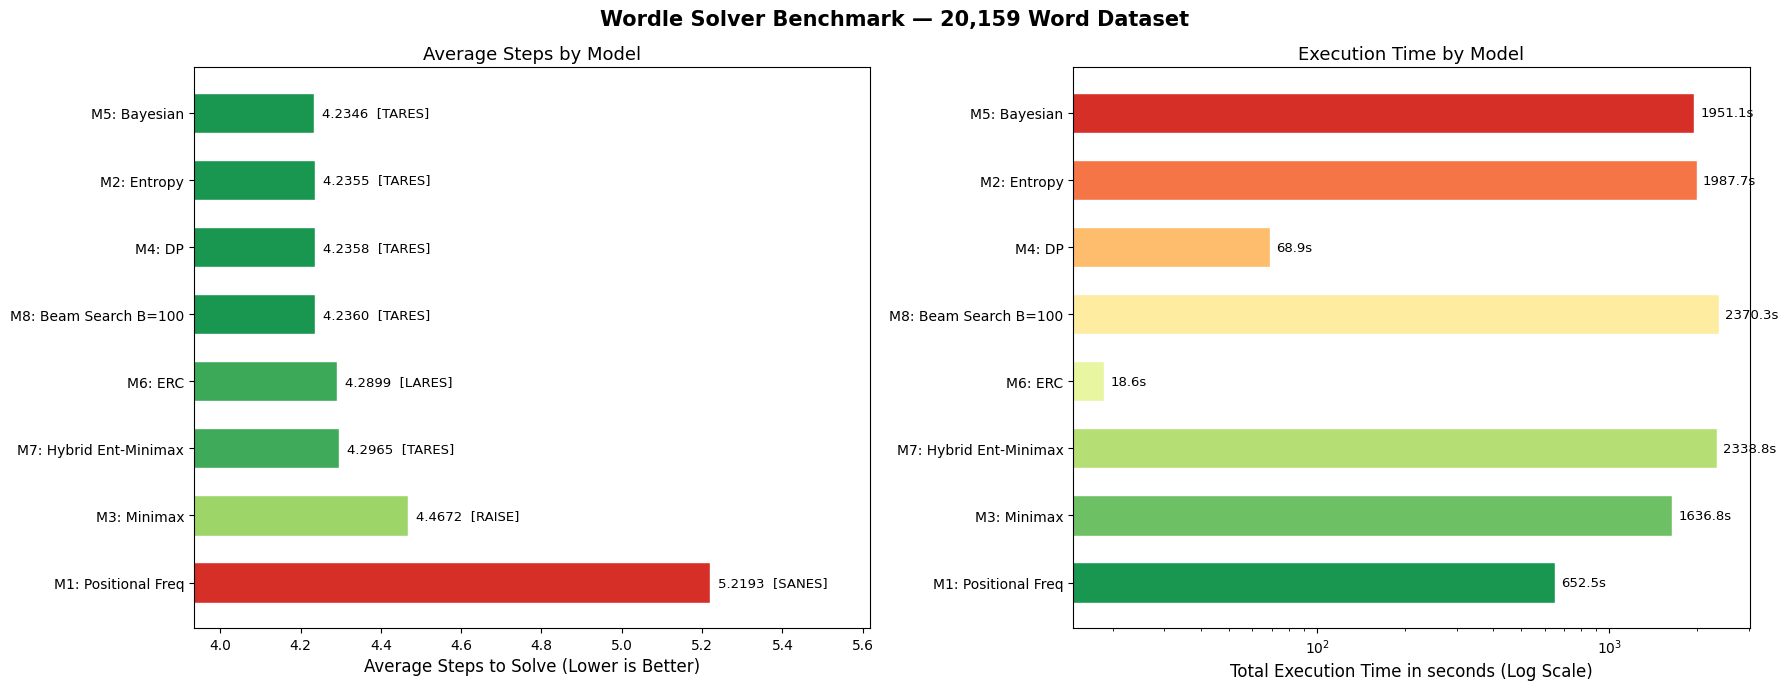

Chart saved to model_comparison.png

🏆 Best Accuracy  : M5: Bayesian  →  4.2346 avg steps
⚡ Fastest Model  : M6: ERC  →  18.6s total

Speed-Accuracy Sweet Spot:
   M4 (DP)  : 4.2358 steps in only 68.9s
   M6 (ERC) : 4.2899 steps in only 18.6s


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Results filled from benchmark outputs ----
results = {
    "M1: Positional Freq":     {"avg": 5.2193, "time": 652.47,   "starter": "SANES"},
    "M2: Entropy":             {"avg": 4.2355, "time": 1987.73,  "starter": "TARES"},
    "M3: Minimax":             {"avg": 4.4672, "time": 1636.79,  "starter": "RAISE"},
    "M4: DP":                  {"avg": 4.2358, "time": 68.86,    "starter": "TARES"},
    "M5: Bayesian":            {"avg": 4.2346, "time": 1951.13,  "starter": "TARES"},
    "M6: ERC":                 {"avg": 4.2899, "time": 18.61,    "starter": "LARES"},
    "M7: Hybrid Ent-Minimax":  {"avg": 4.2965, "time": 2338.82,  "starter": "TARES"},
    "M8: Beam Search B=100":   {"avg": 4.2360, "time": 2370.29,  "starter": "TARES"},
}

# ---- Ranked table ----
print("\n" + "=" * 68)
print(f"   {'MODEL':<28} | {'AVG STEPS':>10} | {'TIME(s)':>8} | STARTER")
print("=" * 68)
for name, r in sorted(results.items(), key=lambda x: x[1]['avg']):
    print(f"   {name:<28} | {r['avg']:>10.4f} | {r['time']:>8.1f} | {r['starter']}")
print("=" * 68)

# ---- Sort by avg steps for plotting ----
sorted_results = sorted(results.items(), key=lambda x: x[1]['avg'])
names  = [k for k, v in sorted_results]
avgs   = [v['avg'] for k, v in sorted_results]
times  = [v['time'] for k, v in sorted_results]
starts = [v['starter'] for k, v in sorted_results]

# ---- Color: green = best (lowest steps), red = worst ----
norm_avgs = np.array(avgs)
norm      = (norm_avgs - norm_avgs.min()) / (norm_avgs.max() - norm_avgs.min())
colors    = plt.cm.RdYlGn_r(norm * 0.8 + 0.1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Wordle Solver Benchmark — 20,159 Word Dataset', fontsize=15, fontweight='bold')

# -- Plot 1: Average Steps (main metric) --
ax = axes[0]
bars = ax.barh(names, avgs, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Average Steps to Solve (Lower is Better)', fontsize=12)
ax.set_title('Average Steps by Model', fontsize=13)
ax.invert_yaxis()
ax.set_xlim(min(avgs) - 0.3, max(avgs) + 0.4)
for bar, avg, starter in zip(bars, avgs, starts):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{avg:.4f}  [{starter}]',
            va='center', fontsize=9.5)

# -- Plot 2: Execution Time (log scale — spans 18s to 2370s) --
ax2 = axes[1]
time_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(names)))
bars2 = ax2.barh(names, times, color=time_colors, edgecolor='white', height=0.6)
ax2.set_xlabel('Total Execution Time in seconds (Log Scale)', fontsize=12)
ax2.set_title('Execution Time by Model', fontsize=13)
ax2.set_xscale('log')
ax2.invert_yaxis()
for bar, t in zip(bars2, times):
    ax2.text(bar.get_width() * 1.05,
             bar.get_y() + bar.get_height() / 2,
             f'{t:.1f}s',
             va='center', fontsize=9.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart saved to model_comparison.png")

# ---- Key insights ----
best_acc   = min(results.items(), key=lambda x: x[1]['avg'])
best_speed = min(results.items(), key=lambda x: x[1]['time'])
print(f"\n🏆 Best Accuracy  : {best_acc[0]}  →  {best_acc[1]['avg']:.4f} avg steps")
print(f"⚡ Fastest Model  : {best_speed[0]}  →  {best_speed[1]['time']:.1f}s total")
print(f"\nSpeed-Accuracy Sweet Spot:")
print(f"   M4 (DP)  : {results['M4: DP']['avg']:.4f} steps in only {results['M4: DP']['time']:.1f}s")
print(f"   M6 (ERC) : {results['M6: ERC']['avg']:.4f} steps in only {results['M6: ERC']['time']:.1f}s")